# 04. Evaluasi Model

Data test hanya berisi 178 hari, sehingga selisih akurasi beberapa persen dapat terjadi secara kebetulan.
Notebook ini memeriksa apakah hasil model benar-benar bermakna secara statistik melalui tiga langkah:
1. Menghitung akurasi minimum agar model dapat dianggap lebih baik daripada prediksi acak.
2. Menghitung interval kepercayaan 95% untuk akurasi setiap model.
3. Membandingkan model dengan fitur berita dan model tanpa fitur berita.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.metrics import confusion_matrix, roc_auc_score

DATA = Path("../data") if Path("../data").exists() else Path("data")  # berjalan dari folder notebook atau folder utama repo
pred = pd.read_csv(DATA / "predictions.csv", parse_dates=["date"])
test = pred[pred.split == "test"].reset_index(drop=True)
y = test["target"].values
n = len(y)
MODELS = [c[6:] for c in test.columns if c.startswith("pred::")]
rng = np.random.default_rng(42)

Matplotlib is building the font cache; this may take a moment.


## 1. Batas Akurasi yang Signifikan
Uji binomial digunakan untuk menentukan jumlah prediksi benar minimum agar hasilnya signifikan
pada tingkat kepercayaan 95%.

In [3]:
majority = max(y.mean(), 1 - y.mean())


def min_significant(p0):
    return next(k for k in range(n) if binomtest(k, n, p0, alternative="greater").pvalue < 0.05) / n


print(f"Proporsi kelas terbanyak di test : {majority:.3f}")
print(f"DA minimum agar signifikan > 50%       : {min_significant(0.5):.3f}")
print(f"DA minimum agar signifikan > mayoritas : {min_significant(majority):.3f}")

Proporsi kelas terbanyak di test : 0.579
DA minimum agar signifikan > 50%       : 0.567
DA minimum agar signifikan > mayoritas : 0.646


## 2. Interval Kepercayaan 95%
Interval kepercayaan dihitung dengan block bootstrap, yaitu mengambil ulang data test secara acak sebanyak
2.000 kali dalam blok lima hari berurutan. Blok digunakan karena hari-hari yang berdekatan saling berkaitan.
Jika interval suatu model masih mencakup 50%, model tersebut belum terbukti lebih baik daripada prediksi acak.

In [4]:
def block_index(block=5):
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return np.concatenate([np.arange(s, s + block) for s in starts])[:n]


IDX = [block_index() for _ in range(2000)]


def ci(stat):
    vals = np.array([stat(i) for i in IDX])
    return np.percentile(vals[~np.isnan(vals)], [2.5, 97.5])


def auc(i, s):
    return roc_auc_score(y[i], s[i]) if len(set(y[i])) > 1 else np.nan


rows = []
for m in MODELS:
    ok = test[f"pred::{m}"].values == y
    row = {"model": m, "DA": ok.mean()}
    row["DA_CI_low"], row["DA_CI_high"] = ci(lambda i: ok[i].mean())
    row["p_vs_50%"] = binomtest(ok.sum(), n, 0.5, alternative="greater").pvalue
    if f"score::{m}" in test:
        s = test[f"score::{m}"].values
        row["AUC"] = roc_auc_score(y, s)
        row["AUC_CI_low"], row["AUC_CI_high"] = ci(lambda i: auc(i, s))
    rows.append(row)
CI = pd.DataFrame(rows).set_index("model")
CI.round(3)

,DA,DA_CI_low,DA_CI_high,p_vs_50%,AUC,AUC_CI_low,AUC_CI_high
model,,,,,,,
Naive: Majority,0.579,0.511,0.652,0.021,NaN,NaN,NaN
Naive: Persistence,0.545,0.489,0.618,0.130,NaN,NaN,NaN
"ARIMA(2,1,0)",0.562,0.494,0.646,0.058,0.516,0.450,0.604
LR [Harga],0.517,0.455,0.590,0.354,0.527,0.453,0.615
HGB [Harga],0.500,0.421,0.573,0.530,0.538,0.445,0.624
LR [NLP],0.517,0.444,0.579,0.354,0.506,0.428,0.572
LR [Harga+NLP],0.517,0.444,0.596,0.354,0.539,0.456,0.624
HGB [Harga+NLP],0.455,0.388,0.534,0.899,0.491,0.415,0.576
LR [Harga+NLP top-k],0.539,0.466,0.612,0.165,0.575,0.500,0.654


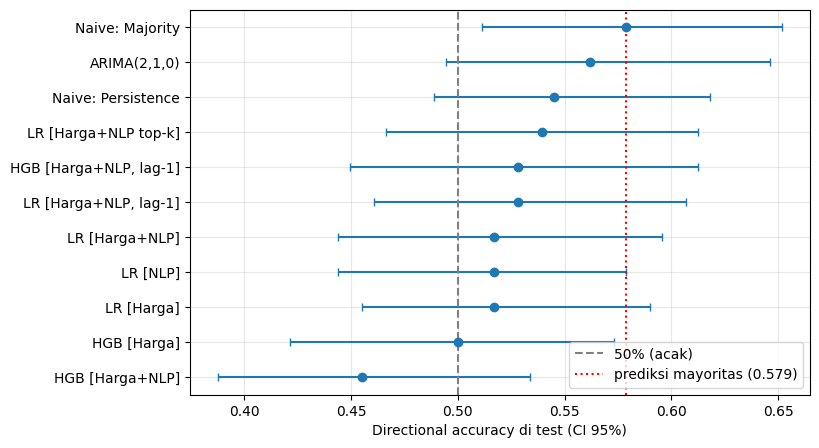

In [5]:
order = CI.sort_values("DA").index
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(CI.loc[order, "DA"], range(len(order)),
            xerr=[CI.loc[order, "DA"] - CI.loc[order, "DA_CI_low"], CI.loc[order, "DA_CI_high"] - CI.loc[order, "DA"]],
            fmt="o", capsize=3)
ax.axvline(0.5, color="gray", ls="--", label="50% (acak)")
ax.axvline(majority, color="red", ls=":", label=f"prediksi mayoritas ({majority:.3f})")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Directional accuracy di test (CI 95%)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.show()

## 3. Kontribusi Fitur Berita
Model dengan fitur berita (A) dibandingkan dengan model tanpa fitur berita (B) pada hari test yang sama.
Jika interval selisihnya mencakup 0, perbedaan kedua model belum terbukti signifikan.

In [6]:
PAIRS = [("LR [Harga+NLP]", "LR [Harga]"), ("HGB [Harga+NLP]", "HGB [Harga]"),
         ("LR [Harga+NLP top-k]", "LR [Harga]"), ("HGB [Harga+NLP, lag-1]", "HGB [Harga]")]
rows = []
for a, b in PAIRS:
    oka, okb = test[f"pred::{a}"].values == y, test[f"pred::{b}"].values == y
    sa, sb = test[f"score::{a}"].values, test[f"score::{b}"].values
    row = {"A": a, "B": b, "selisih_DA": oka.mean() - okb.mean()}
    row["DA_CI_low"], row["DA_CI_high"] = ci(lambda i: oka[i].mean() - okb[i].mean())
    row["selisih_AUC"] = roc_auc_score(y, sa) - roc_auc_score(y, sb)
    row["AUC_CI_low"], row["AUC_CI_high"] = ci(lambda i: auc(i, sa) - auc(i, sb))
    rows.append(row)
pd.DataFrame(rows).round(3)

,A,B,selisih_DA,DA_CI_low,DA_CI_high,selisih_AUC,AUC_CI_low,AUC_CI_high
0,LR [Harga+NLP],LR [Harga],0.000,-0.056,0.056,0.012,-0.042,0.062
1,HGB [Harga+NLP],HGB [Harga],-0.045,-0.124,0.056,-0.047,-0.123,0.050
2,LR [Harga+NLP top-k],LR [Harga],0.022,-0.039,0.079,0.048,-0.007,0.092
3,"HGB [Harga+NLP, lag-1]",HGB [Harga],0.028,-0.045,0.107,-0.049,-0.126,0.043


## 4. Confusion Matrix
Baris menunjukkan kelas sebenarnya dan kolom menunjukkan hasil prediksi.
Kotak diagonal (kiri atas dan kanan bawah) merupakan prediksi yang benar.

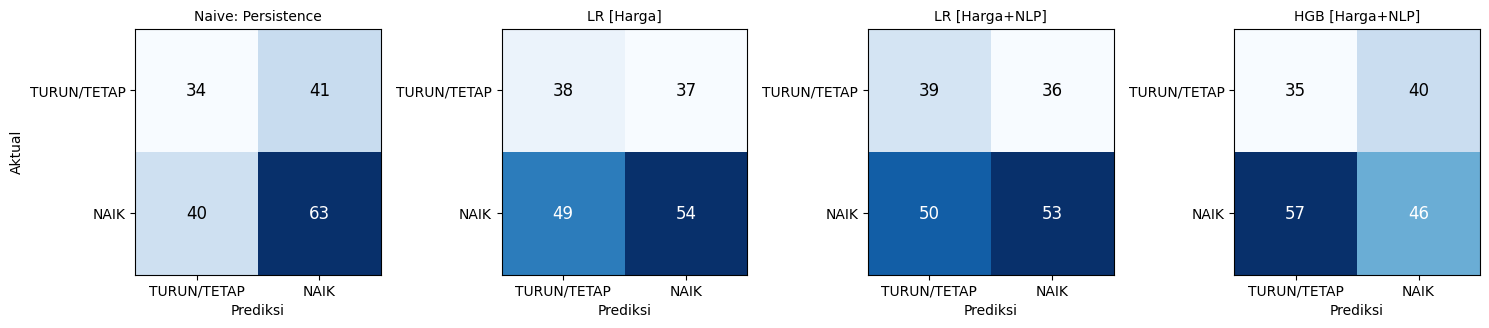

In [7]:
SHOW = ["Naive: Persistence", "LR [Harga]", "LR [Harga+NLP]", "HGB [Harga+NLP]"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, m in zip(axes, SHOW):
    cm = confusion_matrix(y, test[f"pred::{m}"], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.mean() else "black")
    ax.set_xticks([0, 1], ["TURUN/TETAP", "NAIK"])
    ax.set_yticks([0, 1], ["TURUN/TETAP", "NAIK"])
    ax.set_xlabel("Prediksi")
    ax.set_title(m, fontsize=10)
axes[0].set_ylabel("Aktual")
fig.tight_layout()
plt.show()

## 5. Kesimpulan Evaluasi
- Belum ada model yang terbukti lebih baik daripada prediksi "selalu naik".
- Selisih kinerja antara model dengan dan tanpa fitur berita belum signifikan, sehingga kontribusi fitur berita belum terbukti.
- Pembahasan lengkap terdapat pada `notebook/hasil_eksperimen_awal.ipynb` dan laporan.